In [71]:
!pip install -q torch torchvision transformers pillow matplotlib tqdm

In [72]:
import os
import json
import math
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import CLIPProcessor, CLIPModel
from collections import defaultdict
import matplotlib.pyplot as plt

In [73]:
DATASET_DIR = "/content/drive/MyDrive/eng521/Grasp Point Prediction/data/pixmo_subset_v3"
OUTPUT_DIR = "/content/drive/MyDrive/eng521/Grasp Point Prediction/evaluation/Clip_v2"
os.makedirs(OUTPUT_DIR, exist_ok=True)
METADATA_PATH = os.path.join(DATASET_DIR, "metadata.json")
SPLITS_DIR  = os.path.join(DATASET_DIR, "splits")
TRAIN_PATH  = os.path.join(SPLITS_DIR, "train.json")
VAL_PATH    = os.path.join(SPLITS_DIR, "val.json")
TEST_PATH   = os.path.join(SPLITS_DIR, "test.json")
IMAGES_DIR  = os.path.join(DATASET_DIR, "images")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

MODEL_NAME = "openai/clip-vit-base-patch32"

BATCH_SIZE = 16
EPOCHS = 10
LR = 5e-5

DEVICE: cuda


In [74]:
with open(TRAIN_PATH, "r") as f:
    train_data = json.load(f)
with open(VAL_PATH, "r") as f:
    val_data = json.load(f)
with open(TEST_PATH, "r") as f:
    test_data = json.load(f)


print("Train samples:", len(train_data))
print("Val samples:  ", len(val_data))
print("Test samples: ", len(test_data))
print("Example keys:", train_data[0].keys())

Train samples: 548
Val samples:   183
Test samples:  183
Example keys: dict_keys(['id', 'label', 'collection_method', 'count', 'points', 'image_path', 'image_url'])


In [75]:
def normalized_to_unit(pt):
    return float(pt["x"]) / 100.0, float(pt["y"]) / 100.0

def normalized_to_pixel(pt, width, height):
    x = float(pt["x"]) / 100.0 * width
    y = float(pt["y"]) / 100.0 * height
    return (x, y)

def unit_to_pixel(pred_xy, width, height):
    x = float(pred_xy[0]) * width
    y = float(pred_xy[1]) * height
    return (x, y)

def average_point(points):
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    return (sum(xs) / len(xs), sum(ys) / len(ys))

def euclidean_distance(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

SUCCESS_THRESHOLD = 50

def normalized_pixel_error(err, w, h):
    diagonal = math.sqrt(w**2 + h**2)
    return err / diagonal

def make_prompt_point(label):
    hints = {
        "backpack":    "Point to the strap of the backpack.",
        "bag":         "Point to the handle of the bag.",
        "calculator":  "Point to the body of the calculator.",
        "charger":     "Point to the cable of the charger.",
        "hairbrush":   "Point to the handle of the hairbrush.",
        "headphones":  "Point to the band of the headphones.",
        "highlighter": "Point to the body of the highlighter.",
        "jar":         "Point to the lid of the jar.",
        "kettle":      "Point to the handle of the kettle.",
        "keyboard":    "Point to the center of the keyboard.",
        "laptop":      "Point to the edge of the laptop.",
        "mouse":       "Point to the body of the mouse.",
        "notebook":    "Point to the spine of the notebook.",
        "onion":       "Point to the center of the onion.",
        "remote":      "Point to the body of the remote.",
        "scissor":     "Point to the handle of the scissor.",
        "stapler":     "Point to the top of the stapler.",
        "tape":        "Point to the side of the tape.",
        "toothbrush":  "Point to the handle of the toothbrush.",
        "umbrella":    "Point to the handle of the umbrella.",
        "wallet":      "Point to the body of the wallet.",
        "watch":       "Point to the strap of the watch.",
        "apple":       "Point to the center of the apple.",
        "book":        "Point to the spine of the book.",
        "bottle":      "Point to the neck of the bottle.",
        "bowl":        "Point to the rim of the bowl.",
        "cup":         "Point to the handle of the cup.",
        "fork":        "Point to the handle of the fork.",
        "keys":        "Point to the ring of the keys.",
        "knife":       "Point to the handle of the knife.",
        "marker":      "Point to the body of the marker.",
        "mug":         "Point to the handle of the mug.",
        "pen":         "Point to the body of the pen.",
        "phone":       "Point to the body of the phone.",
        "plate":       "Point to the edge of the plate.",
        "shoe":        "Point to the heel of the shoe.",
        "spoon":       "Point to the handle of the spoon.",
        "tomato":      "Point to the center of the tomato.",
        "tray":        "Point to the edge of the tray.",
        "basket":      "Point to the handle of the basket.",
        "pot":         "Point to the handle of the pot.",
        "pan":         "Point to the handle of the pan.",
        "sock":        "Point to the opening of the sock.",
        "glove":       "Point to the cuff of the glove.",
        "t-shirt":     "Point to the collar of the t-shirt.",
        "earbuds":     "Point to the body of the earbuds.",
        "egg":         "Point to the center of the egg.",
        "spatula":     "Point to the handle of the spatula.",
    }
    return hints.get(label.lower(), f"Point to the {label.lower()}.")


def make_prompt_grasp(label):
    hints = {
        "backpack":    "Grasp the strap of the backpack.",
        "bag":         "Grasp the handle of the bag.",
        "calculator":  "Grasp the body of the calculator.",
        "charger":     "Grasp the cable of the charger.",
        "hairbrush":   "Grasp the handle of the hairbrush.",
        "headphones":  "Grasp the band of the headphones.",
        "highlighter": "Grasp the body of the highlighter.",
        "jar":         "Grasp the lid of the jar.",
        "kettle":      "Grasp the handle of the kettle.",
        "keyboard":    "Grasp the center of the keyboard.",
        "laptop":      "Grasp the edge of the laptop.",
        "mouse":       "Grasp the body of the mouse.",
        "notebook":    "Grasp the spine of the notebook.",
        "onion":       "Grasp the center of the onion.",
        "remote":      "Grasp the body of the remote.",
        "scissor":     "Grasp the handle of the scissor.",
        "stapler":     "Grasp the top of the stapler.",
        "tape":        "Grasp the side of the tape.",
        "toothbrush":  "Grasp the handle of the toothbrush.",
        "umbrella":    "Grasp the handle of the umbrella.",
        "wallet":      "Grasp the body of the wallet.",
        "watch":       "Grasp the strap of the watch.",
        "apple":       "Grasp the center of the apple.",
        "book":        "Grasp the spine of the book.",
        "bottle":      "Grasp the neck of the bottle.",
        "bowl":        "Grasp the rim of the bowl.",
        "cup":         "Grasp the handle of the cup.",
        "fork":        "Grasp the handle of the fork.",
        "keys":        "Grasp the ring of the keys.",
        "knife":       "Grasp the handle of the knife.",
        "marker":      "Grasp the body of the marker.",
        "mug":         "Grasp the handle of the mug.",
        "pen":         "Grasp the body of the pen.",
        "phone":       "Grasp the body of the phone.",
        "plate":       "Grasp the edge of the plate.",
        "shoe":        "Grasp the heel of the shoe.",
        "spoon":       "Grasp the handle of the spoon.",
        "tomato":      "Grasp the center of the tomato.",
        "tray":        "Grasp the edge of the tray.",
        "basket":      "Grasp the handle of the basket.",
        "pot":         "Grasp the handle of the pot.",
        "pan":         "Grasp the handle of the pan.",
        "sock":        "Grasp the opening of the sock.",
        "glove":       "Grasp the cuff of the glove.",
        "t-shirt":     "Grasp the collar of the t-shirt.",
        "earbuds":     "Grasp the body of the earbuds.",
        "egg":         "Grasp the center of the egg.",
        "spatula":     "Grasp the handle of the spatula.",
    }
    return hints.get(label.lower(), f"Grasp the {label.lower()}.")


PROMPTS = {"point": make_prompt_point}

#, "grasp": make_prompt_grasp
# def make_prompt(label):
#     grasp_hints = {
#         # Kitchen / Food
#         "apple":      "Point to the center of the apple where you would grasp it.",
#         "onion":      "Point to the center of the onion where you would grasp it.",
#         "tomato":     "Point to the center of the tomato where you would grasp it.",
#         "bottle":     "Point to the neck of the bottle where you would grasp it.",
#         "bowl":       "Point to the rim of the bowl where you would grasp it.",
#         "cup":        "Point to the handle of the cup where you would grasp it.",
#         "mug":        "Point to the handle of the mug where you would grasp it.",
#         "fork":       "Point to the handle of the fork where you would grasp it.",
#         "knife":      "Point to the handle of the knife where you would grasp it.",
#         "spoon":      "Point to the handle of the spoon where you would grasp it.",
#         "plate":      "Point to the edge of the plate where you would grasp it.",
#         "jar":        "Point to the lid of the jar where you would grasp it.",
#         "kettle":     "Point to the handle of the kettle where you would grasp it.",

#         # Stationery / Office
#         "pen":        "Point to the body of the pen where you would grasp it.",
#         "marker":     "Point to the body of the marker where you would grasp it.",
#         "highlighter":"Point to the body of the highlighter where you would grasp it.",
#         "scissor":    "Point to the handle of the scissor where you would grasp it.",
#         "stapler":    "Point to the top of the stapler where you would grasp it.",
#         "tape":       "Point to the side of the tape where you would grasp it.",
#         "calculator": "Point to the body of the calculator where you would grasp it.",
#         "book":       "Point to the spine of the book where you would grasp it.",
#         "notebook":   "Point to the spine of the notebook where you would grasp it.",
#         "keyboard":   "Point to the center of the keyboard where you would grasp it.",

#         # Electronics
#         "phone":      "Point to the body of the phone where you would grasp it.",
#         "laptop":     "Point to the edge of the laptop where you would grasp it.",
#         "mouse":      "Point to the body of the mouse where you would grasp it.",
#         "remote":     "Point to the body of the remote where you would grasp it.",
#         "charger":    "Point to the cable of the charger where you would grasp it.",
#         "headphones": "Point to the band of the headphones where you would grasp it.",

#         # Personal items
#         "backpack":   "Point to the strap of the backpack where you would grasp it.",
#         "bag":        "Point to the handle of the bag where you would grasp it.",
#         "wallet":     "Point to the body of the wallet where you would grasp it.",
#         "watch":      "Point to the strap of the watch where you would grasp it.",
#         "shoe":       "Point to the heel of the shoe where you would grasp it.",
#         "keys":       "Point to the ring of the keys where you would grasp it.",
#         "umbrella":   "Point to the handle of the umbrella where you would grasp it.",
#         "hairbrush":  "Point to the handle of the hairbrush where you would grasp it.",
#     }
#     return grasp_hints.get(label.lower(),
#            f"Point to where you would grasp the {label.lower()}.")

In [76]:
from PIL import Image, UnidentifiedImageError
import os,random

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img.convert("RGB")
        return True
    except (UnidentifiedImageError, OSError, FileNotFoundError):
        return False


class PixmoClipDataset(Dataset):
    def __init__(self, data, images_dir, expand=True):
        self.images_dir = images_dir
        self.data = []
        self.skipped = []

        for d in data:
            if len(d.get("points", [])) == 0:
                self.skipped.append(("no_points", d.get("image_path", "")))
                continue
            self.data.append(d)

        print("Clean dataset size:", len(self.data))
        print("Skipped samples:", len(self.skipped))
        print("First few skipped:", self.skipped[:10])

        self.prompt_list = list(PROMPTS.items())

        if expand:
            # One entry per sample per prompt — for training
            self.expanded = [
                (sample, prompt_name, prompt_fn)
                for sample in self.data
                for prompt_name, prompt_fn in self.prompt_list
            ]
            print("Expanded dataset size:", len(self.expanded))
        else:
            # One entry per sample, fixed to first prompt — for val/test loss only
            self.expanded = [
                (sample, self.prompt_list[0][0], self.prompt_list[0][1])
                for sample in self.data
            ]

    def __len__(self):
        return len(self.expanded)

    def __getitem__(self, idx):
        sample, prompt_name, prompt_fn = self.expanded[idx]

        image_name = os.path.basename(sample["image_path"])
        image_path = os.path.join(self.images_dir, image_name)
        image = Image.open(image_path).convert("RGB")

        gt_points_unit = [normalized_to_unit(pt) for pt in sample["points"]]
        target_x = sum(p[0] for p in gt_points_unit) / len(gt_points_unit)
        target_y = sum(p[1] for p in gt_points_unit) / len(gt_points_unit)

        text = prompt_fn(sample["label"])

        return {
            "image":      image,
            "text":       text,
            "target":     torch.tensor([target_x, target_y], dtype=torch.float32),
            "label":      sample["label"],
            "raw_sample": sample,
            "image_path": image_path,
            "orig_size":  image.size
        }

In [77]:
train_dataset = PixmoClipDataset(train_data, IMAGES_DIR,expand=True)
val_dataset   = PixmoClipDataset(val_data,   IMAGES_DIR, expand=False)
test_dataset  = PixmoClipDataset(test_data,  IMAGES_DIR, expand=False)

print("Train:", len(train_dataset))
print("Val:  ", len(val_dataset))
print("Test: ", len(test_dataset))

Clean dataset size: 548
Skipped samples: 0
First few skipped: []
Expanded dataset size: 548
Clean dataset size: 183
Skipped samples: 0
First few skipped: []
Clean dataset size: 183
Skipped samples: 0
First few skipped: []
Train: 548
Val:   183
Test:  183


In [78]:
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

def collate_fn(batch):
    images = [item["image"] for item in batch]
    texts = [item["text"] for item in batch]
    targets = torch.stack([item["target"] for item in batch])

    enc = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True
    )

    return {
        "pixel_values": enc["pixel_values"],
        "input_ids": enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "targets": targets,
        "meta": batch
    }

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [79]:
class CLIPGraspRegressor(nn.Module):
    def __init__(self, model_name=MODEL_NAME):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(model_name)

        # Freeze all CLIP parameters
        for param in self.clip.parameters():
            param.requires_grad = False

        feat_dim  = self.clip.config.projection_dim
        patch_dim = self.clip.config.vision_config.hidden_size

        # Cross-attention: text as query, image patches as key/value
        self.text_proj  = nn.Linear(feat_dim, patch_dim)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=patch_dim, num_heads=1, batch_first=True
        )
        self.attn_norm  = nn.LayerNorm(patch_dim)

        # Smaller regressor — appropriate for dataset size
        self.regressor = nn.Sequential(
            nn.Linear(feat_dim * 2 + patch_dim, 128),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2),
            nn.Sigmoid()
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        outputs = self.clip(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
            output_hidden_states=True
        )
        image_feats = outputs.image_embeds
        text_feats  = outputs.text_embeds

        patch_feats = outputs.vision_model_output.last_hidden_state[:, 1:, :]

        query   = self.text_proj(text_feats).unsqueeze(1)
        attn_out, _ = self.cross_attn(query, patch_feats, patch_feats)
        spatial = self.attn_norm(attn_out.squeeze(1))

        fused = torch.cat([image_feats, text_feats, spatial], dim=1)
        return self.regressor(fused)

In [80]:
def train_one_epoch(model, loader, optimizer, device, scheduler=None):
    model.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc="train", leave=False):
        pixel_values   = batch["pixel_values"].to(device)
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        targets        = batch["targets"].to(device)

        optimizer.zero_grad()
        preds = model(pixel_values, input_ids, attention_mask)

        # ← CHANGED: smooth_l1 instead of mse
        loss = F.smooth_l1_loss(preds, targets, beta=0.05)
        loss.backward()

        # ← ADDED: gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # ← ADDED: scheduler step
        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item() * targets.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_one_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0

    for batch in tqdm(loader, desc="val", leave=False):
        pixel_values   = batch["pixel_values"].to(device)
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        targets        = batch["targets"].to(device)

        preds = model(pixel_values, input_ids, attention_mask)

        # ← CHANGED: smooth_l1 to match train
        loss = F.smooth_l1_loss(preds, targets, beta=0.05)

        total_loss += loss.item() * targets.size(0)

    return total_loss / len(loader.dataset)

In [81]:
from transformers import get_cosine_schedule_with_warmup

EPOCHS = 40

model = CLIPGraspRegressor().to(DEVICE)

# Sanity check
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
# Expect ~1.5M trainable (<1%) — only cross-attn + regressor

# Only train the new modules — CLIP is fully frozen
optimizer = torch.optim.AdamW([
    {"params": model.text_proj.parameters(),  "lr": 3e-5},
    {"params": model.cross_attn.parameters(), "lr": 3e-5},
    {"params": model.attn_norm.parameters(),  "lr": 3e-5},
    {"params": model.regressor.parameters(),  "lr": 3e-5},
], weight_decay=5e-2)   # stronger weight decay

# Remove warmup — just use constant LR with mild decay
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

best_val_loss    = float("inf")
patience         = 8
patience_counter = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_loss   = eval_one_epoch(model, val_loader, DEVICE)
    scheduler.step()
    print(f"Epoch {epoch+1}/{EPOCHS} | train={train_loss:.4f} | val={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "/content/drive/MyDrive/clip_grasp_best.pt")
        print(f"  ✅ New best: {best_val_loss:.4f} — saved")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(torch.load("/content/drive/MyDrive/clip_grasp_best.pt"))
print("Loaded best model weights for evaluation")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params: 2,987,650 / 154,264,963 (1.9%)


Epoch 1/40 | train=0.1807 | val=0.1834
  ✅ New best: 0.1834 — saved


Epoch 2/40 | train=0.1805 | val=0.1823
  ✅ New best: 0.1823 — saved


...

Epoch 10/40 | train=0.1686 | val=0.1830
  ⏳ No improvement (4/8)


Epoch 11/40 | train=0.1616 | val=0.1813
  ⏳ No improvement (5/8)


Epoch 12/40 | train=0.1580 | val=0.1831
  ⏳ No improvement (6/8)


Epoch 13/40 | train=0.1571 | val=0.1906
  ⏳ No improvement (7/8)


Epoch 14/40 | train=0.1525 | val=0.1858
  ⏳ No improvement (8/8)
Early stopping at epoch 14
Loaded best model weights for evaluation


In [82]:
# @torch.no_grad()
# def evaluate_two_prompts(model, test_data, images_dir, device):
#     model.eval()

#     # Store per-image results for both prompts
#     per_image = {}  # image_path -> {prompt_name -> {pred_x, pred_y, error}}

#     for prompt_name, prompt_fn in PROMPTS.items():
#         print(f"\nRunning inference with prompt: '{prompt_name}'")

#         for sample in tqdm(test_data):
#             image_name = os.path.basename(sample["image_path"])
#             image_path = os.path.join(images_dir, image_name)

#             image = Image.open(image_path).convert("RGB")
#             w, h = image.size
#             text  = prompt_fn(sample["label"])

#             # encode
#             enc = processor(
#                 text=[text],
#                 images=[image],
#                 return_tensors="pt",
#                 padding=True
#             )
#             pixel_values = enc["pixel_values"].to(device)
#             input_ids    = enc["input_ids"].to(device)
#             attention_mask = enc["attention_mask"].to(device)

#             pred = model(pixel_values, input_ids, attention_mask).cpu().numpy()[0]
#             pred_px = unit_to_pixel(pred, w, h)

#             gt_points_px = [normalized_to_pixel(pt, w, h) for pt in sample["points"]]
#             gt_avg = average_point(gt_points_px)
#             err = euclidean_distance(pred_px, gt_avg)
#             norm_err = normalized_pixel_error(err, w, h)

#             if image_path not in per_image:
#                 per_image[image_path] = {
#                     "label": sample["label"],
#                     "gt_x": round(gt_avg[0], 2),
#                     "gt_y": round(gt_avg[1], 2),
#                     "image_w": w,
#                     "image_h": h,
#                     "prompts": {}
#                 }

#             per_image[image_path]["prompts"][prompt_name] = {
#                 "pred_x": round(float(pred_px[0]), 2),
#                 "pred_y": round(float(pred_px[1]), 2),
#                 "pixel_error": round(float(err), 2),
#                 "normalized_pixel_error": round(float(norm_err), 4),
#                 "prompt_text": text
#             }

#     # ─── BUILD OUTPUT JSON ────────────────────────────────────────────────────
#     results = []
#     category_errors = defaultdict(list)   # for per_category_error
#     prompt_errors   = defaultdict(list)   # for per_prompt_error

#     for image_path, info in per_image.items():
#         label = info["label"]
#         p1 = info["prompts"].get("point", {})
#         p2 = info["prompts"].get("grasp",  {})

#         if not p1 or not p2:
#             continue

#         err1 = p1["pixel_error"]
#         err2 = p2["pixel_error"]
#         avg_err = (err1 + err2) / 2.0

#         # prompt_sensitivity: how much the prediction shifts between prompts
#         shift = euclidean_distance(
#             (p1["pred_x"], p1["pred_y"]),
#             (p2["pred_x"], p2["pred_y"])
#         )

#         # prompt_consistency: 1 - normalized shift (higher = more consistent)
#         diag = math.sqrt(info["image_w"]**2 + info["image_h"]**2)
#         consistency = round(1.0 - (shift / diag), 4)

#         # success rate: 1 if both prompts within threshold
#         success = int(err1 < SUCCESS_THRESHOLD and err2 < SUCCESS_THRESHOLD)

#         entry = {
#             "image_path": image_path,
#             "label": label,
#             # prompt 1 (point)
#             "prompt_1": p1["prompt_text"],
#             "pred_x_point": p1["pred_x"],
#             "pred_y_point": p1["pred_y"],
#             "pixel_error_point": err1,
#             "normalized_pixel_error_point": p1["normalized_pixel_error"],
#             # prompt 2 (grasp)
#             "prompt_2": p2["prompt_text"],
#             "pred_x_grasp": p2["pred_x"],
#             "pred_y_grasp": p2["pred_y"],
#             "pixel_error_grasp": err2,
#             "normalized_pixel_error_grasp": p2["normalized_pixel_error"],
#             # ground truth
#             "gt_x": info["gt_x"],
#             "gt_y": info["gt_y"],
#             # aggregate metrics
#             "avg_pixel_error": round(avg_err, 2),
#             "prompt_sensitivity": round(shift, 2),
#             "prompt_consistency": consistency,
#             "success_rate": success,
#         }

#         results.append(entry)
#         category_errors[label].append(avg_err)
#         prompt_errors["point"].append(err1)
#         prompt_errors["grasp"].append(err2)

#     # ─── AGGREGATE METRICS ────────────────────────────────────────────────────
#     per_category = {
#         cat: round(float(np.mean(errs)), 2)
#         for cat, errs in category_errors.items()
#     }
#     per_prompt = {
#         p: round(float(np.mean(errs)), 2)
#         for p, errs in prompt_errors.items()
#     }

#     print("\n=== EVALUATION SUMMARY ===")
#     print(f"Total samples evaluated: {len(results)}")
#     print(f"Mean pixel error (point prompt): {per_prompt['point']}")
#     print(f"Mean pixel error (grasp prompt): {per_prompt['grasp']}")
#     print(f"\nPer-category mean error:")
#     for cat, err in sorted(per_category.items()):
#         print(f"  {cat}: {err}")

#     return results, per_category, per_prompt

In [83]:
@torch.no_grad()
def run_prompt(model, data, images_dir, device, prompt_name, prompt_fn, split):
    """Run inference for one prompt. Returns list of per-image result dicts."""
    model.eval()
    results = []

    for i, sample in enumerate(tqdm(data, desc=f"  {prompt_name}")):
        image_name = os.path.basename(sample["image_path"])
        image_path = os.path.join(images_dir, image_name)
        label = sample["label"]

        image = Image.open(image_path).convert("RGB")
        w, h = image.size

        # ← uses prompt function, not template string
        text = prompt_fn(label)

        enc = processor(
            text=[text], images=[image],
            return_tensors="pt", padding=True
        )
        pixel_values   = enc["pixel_values"].to(device)
        input_ids      = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)

        pred = model(pixel_values, input_ids, attention_mask).cpu().numpy()[0]
        pred_px = unit_to_pixel(pred, w, h)

        gt_points_px = [normalized_to_pixel(pt, w, h) for pt in sample["points"]]
        gt_avg   = average_point(gt_points_px)
        err      = euclidean_distance(pred_px, gt_avg)
        norm_err = normalized_pixel_error(err, w, h)

        results.append({
            "id":         sample.get("id", i),
            "split":      split,
            "image_path": image_path,
            "filename":   image_name,
            "label":      label,
            "prompt":     text,
            "pred_x":     round(float(pred_px[0]), 6),
            "pred_y":     round(float(pred_px[1]), 6),
            "pred_point": [round(float(pred_px[0]), 6), round(float(pred_px[1]), 6)],
            "gt_x":       round(float(gt_avg[0]), 6),
            "gt_y":       round(float(gt_avg[1]), 6),
            "gt_point":   [round(float(gt_avg[0]), 6), round(float(gt_avg[1]), 6)],
            "pixel_error":            round(float(err), 6),
            "normalized_pixel_error": round(float(norm_err), 6),
            "error":            round(float(err), 6),
            "normalized_error": round(float(norm_err), 6),
            "success": int(err < SUCCESS_THRESHOLD),
            "status":  "ok",
            "score":      None,
            "best_label": None,
        })

    return results


def _prompt_summary(results, prompt_name):
    valid = [r for r in results if r["pixel_error"] is not None]
    n, nv = len(results), len(valid)
    return {
        "template":              prompt_name,
        "mean_error":            float(np.mean([r["pixel_error"]            for r in valid])) if valid else None,
        "mean_normalized_error": float(np.mean([r["normalized_pixel_error"] for r in valid])) if valid else None,
        "success_rate":          float(np.mean([r["success"]                for r in valid])) if valid else None,
        "detection_rate":        nv / n if n > 0 else 0.0,
        "num_samples": n,
        "num_valid":   nv,
    }


def evaluate_all_prompts(model, data, images_dir, device, split, output_dir):
    """
    Run all PROMPTS on `data`. Saves:
      clip_{split}_prompt_eval.json
      clip_{split}_prompt_summary.json
    Returns (prompt_eval, prompt_summary_sorted, best_prompt_name).
    """
    prompt_eval    = []
    prompt_summary = []

    # ← iterates PROMPTS dict, not PROMPT_TEMPLATES list
    for prompt_name, prompt_fn in PROMPTS.items():
        print(f"\nPrompt: '{prompt_name}'")
        results = run_prompt(model, data, images_dir, device, prompt_name, prompt_fn, split)
        summ    = _prompt_summary(results, prompt_name)

        details = [{
            "id":               r["id"],
            "label":            r["label"],
            "prompt":           r["prompt"],
            "filename":         r["filename"],
            "gt_point":         r["gt_point"],
            "pred_point":       r["pred_point"],
            "error":            r["error"],
            "normalized_error": r["normalized_error"],
            "score":            r["score"],
            "best_label":       r["best_label"],
            "status":           r["status"],
        } for r in results]

        prompt_eval.append({**summ, "details": details})
        prompt_summary.append(summ)
        print(f"  mean_error={summ['mean_error']:.4f} | success_rate={summ['success_rate']:.4f}")

    prompt_summary_sorted = sorted(prompt_summary, key=lambda x: x["mean_error"])
    best_prompt_name = prompt_summary_sorted[0]["template"]
    print(f"\n✅ Best prompt on '{split}': '{best_prompt_name}'")

    prefix = f"clip_{split}"
    with open(os.path.join(output_dir, f"{prefix}_prompt_eval.json"),    "w") as f:
        json.dump(prompt_eval,           f, indent=2)
    with open(os.path.join(output_dir, f"{prefix}_prompt_summary.json"), "w") as f:
        json.dump(prompt_summary_sorted, f, indent=2)

    print(f"Saved: {prefix}_prompt_eval.json, {prefix}_prompt_summary.json")
    return prompt_eval, prompt_summary_sorted, best_prompt_name


def evaluate_with_best_prompt(model, data, images_dir, device, split, best_prompt_name, output_dir):
    """
    Run inference with best prompt on `data`. Saves:
      clip_{split}_final_per_image.json
      clip_{split}_final_per_category.json
      clip_{split}_final_summary.json
    """
    # ← look up the function from the name
    prompt_fn = PROMPTS[best_prompt_name]

    print(f"\nEvaluating '{split}' with best prompt: '{best_prompt_name}'")
    results = run_prompt(model, data, images_dir, device, best_prompt_name, prompt_fn, split)

    per_image = [{
        "split":                    r["split"],
        "image_path":               r["image_path"],
        "label":                    r["label"],
        "prompt":                   r["prompt"],
        "pred_x":                   r["pred_x"],
        "pred_y":                   r["pred_y"],
        "gt_x":                     r["gt_x"],
        "gt_y":                     r["gt_y"],
        "pixel_error":              r["pixel_error"],
        "normalized_pixel_error":   r["normalized_pixel_error"],
        "success":                  r["success"],
        "status":                   r["status"],
        "score":                    r["score"],
        "best_label":               r["best_label"],
        "best_prompt_from_val":     best_prompt_name,
        "prompt_sensitivity":       None,
        "prompt_consistency":       None,
    } for r in results]

    cat_groups = defaultdict(list)
    for r in results:
        cat_groups[r["label"]].append(r)

    per_category = []
    for label, recs in sorted(cat_groups.items(),
                               key=lambda x: np.mean([r["pixel_error"] for r in x[1]])):
        valid = [r for r in recs if r["pixel_error"] is not None]
        n, nv = len(recs), len(valid)
        per_category.append({
            "label":                 label,
            "num_samples":           n,
            "num_valid":             nv,
            "mean_error":            float(np.mean([r["pixel_error"]            for r in valid])) if valid else None,
            "mean_normalized_error": float(np.mean([r["normalized_pixel_error"] for r in valid])) if valid else None,
            "success_rate":          float(np.mean([r["success"]                for r in valid])) if valid else None,
            "detection_rate":        nv / n if n > 0 else 0.0,
        })

    valid_all = [r for r in results if r["pixel_error"] is not None]
    final_summary = {
        "split":              split,
        "best_prompt":        best_prompt_name,
        "success_rate":       float(np.mean([r["success"] for r in valid_all])) if valid_all else None,
        "per_prompt_error":   {best_prompt_name: float(np.mean([r["pixel_error"] for r in valid_all]))} if valid_all else {},
        "per_category_error": {pc["label"]: pc["mean_error"] for pc in per_category},
        "prompt_sensitivity": None,
        "prompt_consistency": None,
    }

    prefix = f"clip_{split}"
    with open(os.path.join(output_dir, f"{prefix}_final_per_image.json"),    "w") as f:
        json.dump(per_image,     f, indent=2)
    with open(os.path.join(output_dir, f"{prefix}_final_per_category.json"), "w") as f:
        json.dump(per_category,  f, indent=2)
    with open(os.path.join(output_dir, f"{prefix}_final_summary.json"),      "w") as f:
        json.dump(final_summary, f, indent=2)

    print(f"Saved: {prefix}_final_per_image.json, _per_category.json, _final_summary.json")
    return per_image, per_category, final_summary

In [84]:
# results, per_category_error, per_prompt_error = evaluate_two_prompts(
#     model, test_data, IMAGES_DIR, DEVICE
# )

# # Add aggregate metrics to each entry
# for r in results:
#     r["per_category_error"] = per_category_error[r["label"]]
#     r["per_prompt_error_point"] = per_prompt_error["point"]
#     r["per_prompt_error_grasp"] = per_prompt_error["grasp"]

# EVAL_SAVE_PATH = "/content/drive/MyDrive/eng521/Grasp Point Prediction/Evaluation/Clip/clip_eval_results_2prompt.json"
# with open(EVAL_SAVE_PATH, "w") as f:
#     json.dump(results, f, indent=2)

# print(f"\n✅ Saved {len(results)} results to {EVAL_SAVE_PATH}")


# errors_point = [r["pixel_error_point"] for r in results]
# errors_grasp  = [r["pixel_error_grasp"]  for r in results]
# sensitivity   = [r["prompt_sensitivity"] for r in results]
# consistency   = [r["prompt_consistency"] for r in results]
# success       = [r["success_rate"]       for r in results]

# print("\n========== EVALUATION SUMMARY ==========")
# print(f"Total samples        : {len(results)}")

# print("\n--- Pixel Error (Point Prompt) ---")
# print(f"  Mean   : {np.mean(errors_point):.2f} px")
# print(f"  Median : {np.median(errors_point):.2f} px")
# print(f"  Std    : {np.std(errors_point):.2f} px")
# print(f"  Min    : {np.min(errors_point):.2f} px")
# print(f"  Max    : {np.max(errors_point):.2f} px")

# print("\n--- Pixel Error (Grasp Prompt) ---")
# print(f"  Mean   : {np.mean(errors_grasp):.2f} px")
# print(f"  Median : {np.median(errors_grasp):.2f} px")
# print(f"  Std    : {np.std(errors_grasp):.2f} px")
# print(f"  Min    : {np.min(errors_grasp):.2f} px")
# print(f"  Max    : {np.max(errors_grasp):.2f} px")

# print("\n--- Prompt Sensitivity (pred shift between prompts) ---")
# print(f"  Mean   : {np.mean(sensitivity):.2f} px")
# print(f"  Median : {np.median(sensitivity):.2f} px")

# print("\n--- Prompt Consistency (1=identical, 0=very different) ---")
# print(f"  Mean   : {np.mean(consistency):.4f}")

# print("\n--- Success Rate (both prompts within 50px threshold) ---")
# print(f"  {np.mean(success)*100:.1f}% ({sum(success)}/{len(success)} samples)")

# print("\n--- Per Category Mean Error (avg of both prompts) ---")
# for cat, err in sorted(per_category_error.items()):
#     print(f"  {cat:<15}: {err:.2f} px")

# print("\n--- Per Prompt Mean Error ---")
# print(f"  point : {per_prompt_error['point']:.2f} px")
# print(f"  grasp : {per_prompt_error['grasp']:.2f} px")
# print("=========================================")

In [85]:
# ── 1. Find best prompt on val ─────────────────────────────────────────────
val_prompt_eval, val_prompt_summary, BEST_PROMPT = evaluate_all_prompts(
    model, val_data, IMAGES_DIR, DEVICE, split="val", output_dir=OUTPUT_DIR
)

# ── 2. Final val evaluation with best prompt ───────────────────────────────
val_per_image, val_per_category, val_final_summary = evaluate_with_best_prompt(
    model, val_data, IMAGES_DIR, DEVICE,
    split="val", best_prompt_name=BEST_PROMPT, output_dir=OUTPUT_DIR
)

# ── 3. Final test evaluation with best prompt ──────────────────────────────
test_per_image, test_per_category, test_final_summary = evaluate_with_best_prompt(
    model, test_data, IMAGES_DIR, DEVICE,
    split="test", best_prompt_name=BEST_PROMPT, output_dir=OUTPUT_DIR
)

print("\n========== FINAL RESULTS ==========")
print(f"Best prompt (from val) : '{BEST_PROMPT}'")
print(f"Val  success rate      : {val_final_summary['success_rate']:.4f}")
print(f"Test success rate      : {test_final_summary['success_rate']:.4f}")
print(f"\nTest per-category error (sorted):")
for cat, err in sorted(test_final_summary["per_category_error"].items(), key=lambda x: x[1]):
    print(f"  {cat:<15}: {err:.2f} px")
print("====================================")


Prompt: 'point'


  point: 100%|██████████| 183/183 [00:09<00:00, 18.75it/s]


  mean_error=322.1424 | success_rate=0.0765

✅ Best prompt on 'val': 'point'
Saved: clip_val_prompt_eval.json, clip_val_prompt_summary.json

Evaluating 'val' with best prompt: 'point'


  point: 100%|██████████| 183/183 [00:08<00:00, 22.03it/s]


Saved: clip_val_final_per_image.json, _per_category.json, _final_summary.json

Evaluating 'test' with best prompt: 'point'


  point: 100%|██████████| 183/183 [00:10<00:00, 18.09it/s]

Saved: clip_test_final_per_image.json, _per_category.json, _final_summary.json

========== FINAL RESULTS ==========
Best prompt (from val) : 'point'
Val  success rate      : 0.0765
Test success rate      : 0.0273

Test per-category error (sorted):
  spatula        : 89.21 px
  mouse          : 127.10 px
  umbrella       : 132.34 px
  tomato         : 138.76 px
  onion          : 144.95 px
  egg            : 165.38 px
  keys           : 169.23 px
  book           : 170.39 px
  knife          : 180.62 px
  stapler        : 180.87 px
  pen            : 187.77 px
  watch          : 193.31 px
  shoe           : 209.11 px
  spoon          : 213.94 px
  mug            : 215.52 px
  phone          : 216.83 px
  hairbrush      : 221.75 px
  calculator     : 227.26 px
  t-shirt        : 227.74 px
  remote         : 238.66 px
  bowl           : 239.78 px
  scissor        : 250.39 px
  sock           : 260.76 px
  plate          : 261.96 px
  bottle         : 265.25 px
  kettle         : 270.41 px

In [86]:

import random as rnd

def get_attention_map(model, image, text, device):
    model.eval()
    with torch.no_grad():
        enc = processor(text=[text], images=[image], return_tensors="pt", padding=True)
        pixel_values   = enc["pixel_values"].to(device)
        input_ids      = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)

        outputs = model.clip(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
            output_hidden_states=True
        )
        text_feats  = outputs.text_embeds
        patch_feats = outputs.vision_model_output.last_hidden_state[:, 1:, :]

        query = model.text_proj(text_feats).unsqueeze(1)
        _, attn_weights = model.cross_attn(
            query, patch_feats, patch_feats,
            need_weights=True, average_attn_weights=True
        )
        attn = attn_weights.squeeze().cpu().numpy()

        # Dynamically compute grid size from actual patch count
        n_patches = attn.shape[0]
        grid_size = int(n_patches ** 0.5)
        assert grid_size * grid_size == n_patches, \
            f"Non-square patch grid: {n_patches} patches"

        return attn.reshape(grid_size, grid_size)


def visualize_attention(model, sample, images_dir, device):
    image_path = os.path.join(images_dir, os.path.basename(sample["image_path"]))
    image = Image.open(image_path).convert("RGB")
    w, h  = image.size
    text  = PROMPTS[BEST_PROMPT](sample["label"])

    attn = get_attention_map(model, image, text, device)

    enc = processor(text=[text], images=[image], return_tensors="pt", padding=True)
    with torch.no_grad():
        pred = model(
            enc["pixel_values"].to(device),
            enc["input_ids"].to(device),
            enc["attention_mask"].to(device)
        ).cpu().numpy()[0]

    pred_px = unit_to_pixel(pred, w, h)
    gt_px   = average_point([normalized_to_pixel(pt, w, h) for pt in sample["points"]])
    err     = euclidean_distance(pred_px, gt_px)

    heat     = (attn - attn.min()) / (attn.max() - attn.min() + 1e-8)
    heat_img = Image.fromarray(
        (plt.cm.jet(heat)[:, :, :3] * 255).astype(np.uint8)
    ).resize((w, h), Image.BILINEAR)
    blended  = Image.blend(image, heat_img, alpha=0.5)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(blended)
    axes[1].scatter(*pred_px, s=150, c="red",   marker="x", label="Pred", zorder=5)
    axes[1].scatter(*gt_px,   s=150, c="green", marker="o", label="GT",   zorder=5)
    axes[1].set_title(f"Attention + Prediction\nerr={err:.1f}px | '{text}'")
    axes[1].legend()
    axes[1].axis("off")

    axes[2].imshow(attn, cmap="jet", interpolation="bilinear")
    axes[2].set_title(f"Raw Attention ({attn.shape[0]}×{attn.shape[1]})")
    axes[2].axis("off")

    status = "✓" if err < SUCCESS_THRESHOLD else "✗"
    plt.suptitle(f"{sample['label']} | {status}", fontsize=13)
    plt.tight_layout()
    plt.show()
def visualize_attention_grid(model, data, images_dir, device, n=6, mode="random", label=None):
    """
    mode = "random"  → pick n random samples
    mode = "best"    → pick n lowest error samples (needs test_per_image)
    mode = "worst"   → pick n highest error samples (needs test_per_image)
    mode = "label"   → pick n samples of a specific label
    """
    if mode == "random":
        samples = rnd.sample(data, min(n, len(data)))

    elif mode == "label":
        assert label is not None, "Provide a label name"
        samples = [s for s in data if s["label"] == label][:n]
        if not samples:
            print(f"No samples found for label '{label}'")
            return

    elif mode in ("best", "worst"):
        # needs test_per_image from evaluation
        reverse = (mode == "worst")
        sorted_results = sorted(
            test_per_image,
            key=lambda r: r["pixel_error"],
            reverse=reverse
        )[:n]
        path_to_sample = {
            os.path.join(images_dir, os.path.basename(s["image_path"])): s
            for s in data
        }
        samples = [
            path_to_sample[r["image_path"]]
            for r in sorted_results
            if r["image_path"] in path_to_sample
        ]

    for sample in samples:
        visualize_attention(model, sample, images_dir, device)


def visualize_by_category(model, data, images_dir, device, categories=None):
    """
    Visualize one sample per category.
    categories = None → all categories in data
    categories = ["knife", "cup", "pan"] → specific ones
    """
    if categories is None:
        # get all unique labels
        categories = sorted(set(s["label"] for s in data))

    for cat in categories:
        sample = next((s for s in data if s["label"] == cat), None)
        if sample:
            print(f"\n--- {cat} ---")
            visualize_attention(model, sample, images_dir, device)
        else:
            print(f"No sample found for: {cat}")

In [87]:
def show_prediction(per_image_results, idx=0):
    row = per_image_results[idx]
    img = Image.open(row["image_path"]).convert("RGB")

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.scatter(row["gt_x"],   row["gt_y"],   s=150, marker="o", color="green", label="GT")
    plt.scatter(row["pred_x"], row["pred_y"],  s=150, marker="x", color="red",
                label=f"Pred (err={row['pixel_error']:.1f}px)")

    status_str = "✓" if row["success"] == 1 else "✗"
    plt.title(f"{row['label']} | {status_str} | err={row['pixel_error']:.1f}px | {row['prompt']}")
    plt.legend()
    plt.axis("off")
    plt.show()

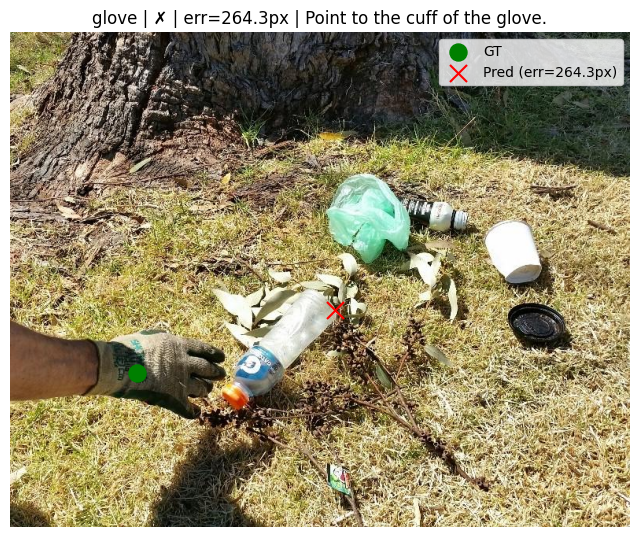

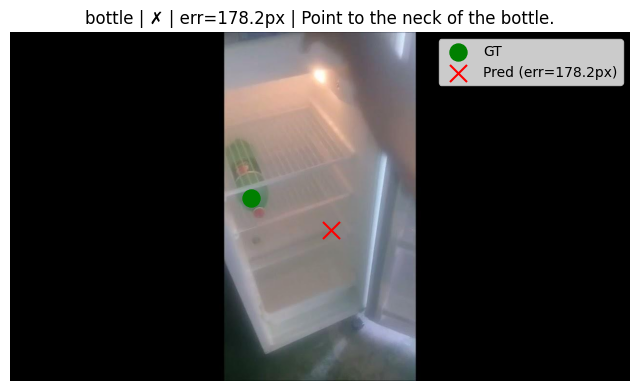

In [88]:
show_prediction(test_per_image, idx=50)
show_prediction(test_per_image, idx=20)

In [89]:
# Sort test_per_image by error (run evaluation first)
worst_samples = sorted(test_per_image, key=lambda r: r["pixel_error"], reverse=True)[:5]
best_samples  = sorted(test_per_image, key=lambda r: r["pixel_error"])[:5]

# Map back to raw test_data by image path
test_data_by_path = {
    os.path.join(IMAGES_DIR, os.path.basename(s["image_path"])): s
    for s in test_data
}

print("=== WORST PREDICTIONS ===")
for r in worst_samples:
    sample = test_data_by_path.get(r["image_path"])
    if sample:
        visualize_attention(model, sample, IMAGES_DIR, DEVICE)

print("=== BEST PREDICTIONS ===")
for r in best_samples:
    sample = test_data_by_path.get(r["image_path"])
    if sample:
        visualize_attention(model, sample, IMAGES_DIR, DEVICE)

Output hidden; open in https://colab.research.google.com to view.

In [90]:
torch.save(model.state_dict(), "/content/drive/MyDrive/clip_grasp_model_multipleprompt.pt")

In [91]:
# 6 random test samples
visualize_attention_grid(model, test_data, IMAGES_DIR, DEVICE, n=6, mode="random")

# 5 best predictions
visualize_attention_grid(model, test_data, IMAGES_DIR, DEVICE, n=5, mode="best")

# 5 worst predictions
visualize_attention_grid(model, test_data, IMAGES_DIR, DEVICE, n=5, mode="worst")

# All samples of one category
visualize_attention_grid(model, test_data, IMAGES_DIR, DEVICE, n=5, mode="label", label="knife")
visualize_attention_grid(model, test_data, IMAGES_DIR, DEVICE, n=5, mode="label", label="cup")

# One image per category — full survey
visualize_by_category(model, test_data, IMAGES_DIR, DEVICE)

# Specific categories only
visualize_by_category(model, test_data, IMAGES_DIR, DEVICE,
    categories=["knife", "cup", "pan", "keyboard", "bottle", "scissor"])

Output hidden; open in https://colab.research.google.com to view.